# Mental Health Risk Prediction
### CSC 108 — Final Project by Hayden Budhan

---

This project uses a dataset of 25,000 individuals to analyze lifestyle and psychological factors associated with mental health risk. We perform exploratory data analysis, data visualization, and build machine learning models to predict risk levels.

**Dataset:** `mental_health_risk_dataset.csv`  (25,000 entries, 25 features)

**Target Variable:** `mental_health_risk` (multi-class)

**This project is OPEN to be shared with future classes!**

---
## Section 1: Setup & Data Loading

We begin by importing the necessary libraries and loading the dataset from Google Drive.

In [ ]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
mental_health_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mental_health_risk_dataset.csv')


Mounted at /content/drive


---
## Section 2: Exploratory Data Analysis

We examine the structure, data types, and summary statistics of the dataset.

In [ ]:
# Let's display the first 5 rows to see what our data looks like
mental_health_data.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


In [ ]:
mental_health_data.info() # Shows data types, missing values, and columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  object 
 2   marital_status                    25000 non-null  object 
 3   education_level                   25000 non-null  object 
 4   employment_status                 25000 non-null  object 
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            25000 non-null  int64  
 12  fina

In [ ]:
mental_health_data.describe() # Shows summary statistics

,age,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,39.072560,6.509516,7.515400,6.469132,5.50840,5.517080,5.445880,5.471040,5.495080,45.049600,...,5.534000,5.520480,5.512880,5.488240,0.497840,0.504280,0.504160,0.501640,0.499120,0.778520
std,12.404948,2.015586,4.324346,3.167682,2.88694,2.864548,2.864479,2.867816,2.881636,14.683297,...,2.870048,2.873213,2.870596,2.873178,0.500005,0.499992,0.499993,0.500007,0.500009,0.691409
min,18.000000,3.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,20.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,4.800000,3.800000,3.700000,3.00000,3.000000,3.000000,3.000000,3.000000,32.000000,...,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,6.500000,7.500000,6.500000,5.00000,6.000000,5.000000,5.000000,5.000000,45.000000,...,6.000000,6.000000,6.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,50.000000,8.200000,11.300000,9.200000,8.00000,8.000000,8.000000,8.000000,8.000000,58.000000,...,8.000000,8.000000,8.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,60.000000,10.000000,15.000000,12.000000,10.00000,10.000000,10.000000,10.000000,10.000000,70.000000,...,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


---
## Section 3: Data Visualization

We explore key relationships in the data through visualizations.

### Screen Time vs. Mental Health Risk

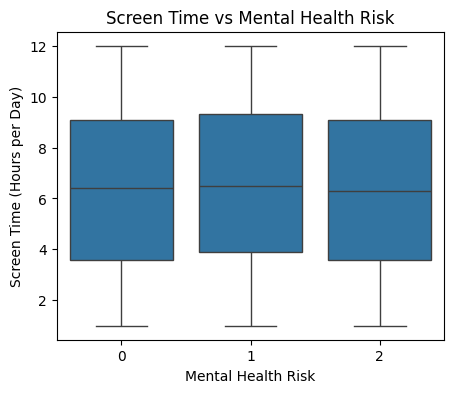

In [ ]:
# Now we create a boxplot: Screen Time vs Mental Health Risk
plt.figure(figsize=(5,4))  # set figure size
sns.boxplot(x="mental_health_risk", y="screen_time_hours_per_day", data=mental_health_data)

plt.xlabel("Mental Health Risk")
plt.ylabel("Screen Time (Hours per Day)")
plt.title("Screen Time vs Mental Health Risk")

plt.show()

This visualization shows the relationship between screen time and mental health risk. The distribution of screen time is similar across all risk levels, with no clear increasing or decreasing trend. This suggests that screen time may not be a strong predictor of mental health risk compared to other factors.

### Correlation Heatmap

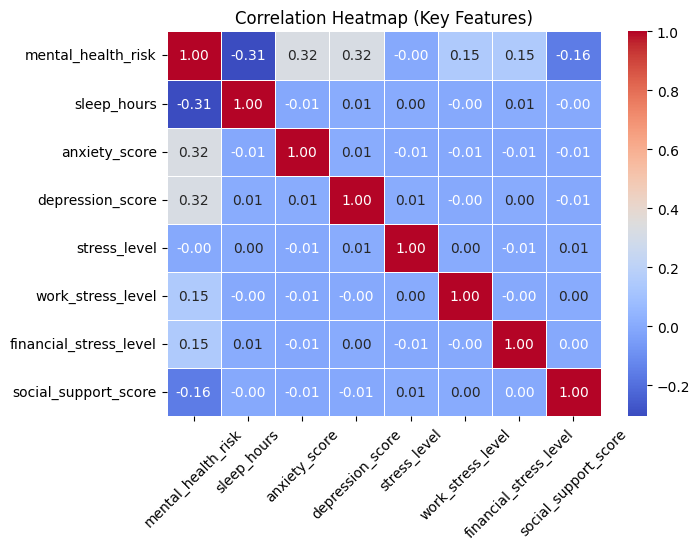

In [ ]:
# To make a heatmap , we select some important variables from the dataset
selected_columns = [
    "mental_health_risk",
    "sleep_hours",
    "anxiety_score",
    "depression_score",
    "stress_level",
    "work_stress_level",
    "financial_stress_level",
    "social_support_score"
]

focused_data = mental_health_data[selected_columns]

# Correlation matrix
correlation_matrix = focused_data.corr()

plt.figure(figsize=(7,5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f", # round numbers to 2 decimals
    cmap="coolwarm",
    linewidths=0.5 # adds spacing between boxes
)

plt.title("Correlation Heatmap (Key Features)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

The correlation heatmap shows that anxiety and depression scores have the strongest positive relationships with mental health risk, while sleep hours have a negative relationship. Work and financial stress show moderate correlations, while other variables such as general stress and social support have weaker relationships. These results suggest that psychological factors and sleep are the most important predictors of mental health risk in this dataset.

---
## Section 4: Predictive Modeling

In this section, we build and evaluate machine learning models to predict mental health risk levels.

### Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split # split data
from sklearn.linear_model import LogisticRegression # prediction model
from sklearn.metrics import accuracy_score # evaluation

features = [
    "sleep_hours",
    "anxiety_score",
    "depression_score",
    "work_stress_level",
    "financial_stress_level",
    "social_support_score"
]

X = mental_health_data[features]  # input variables
y = mental_health_data["mental_health_risk"]  # target variable

# We split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the model
model = LogisticRegression(max_iter=1000)  # increase iterations to avoid errors

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.6116


The model achieved an accuracy of approximately 61%, indicating that mental health risk can be predicted better than random chance using the selected features. However, the moderate accuracy suggests that while factors such as sleep, anxiety, and stress contribute to prediction, mental health risk is influenced by additional factors not captured in the dataset.

### Confusion Matrix

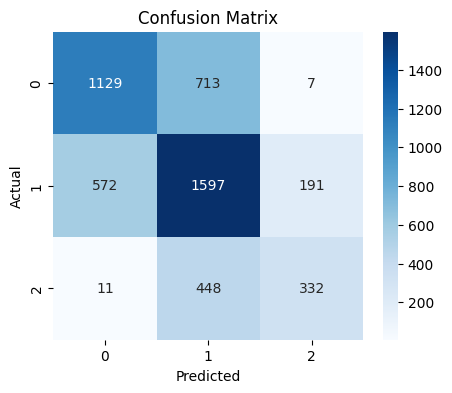

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows that the model performs best when predicting medium mental health risk, with a high number of correct classifications. However, the model frequently misclassifies low and high risk individuals as medium risk. This suggests that while the model can identify general patterns, it has difficulty distinguishing between the extremes of mental health risk.

### Feature Importance Analysis

In [ ]:
# Get feature importance (coefficients)
importance = model.coef_

# Create DataFrame for readability
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance[0]  # use first row for simplicity
})

# Sort values
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

                  Feature  Importance
0             sleep_hours    0.351293
5    social_support_score    0.123021
4  financial_stress_level   -0.124249
3       work_stress_level   -0.124403
2        depression_score   -0.259633
1           anxiety_score   -0.259979


### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42) # create model

dt_model.fit(X_train, y_train) # train model

dt_pred = dt_model.predict(X_test) # predict

dt_accuracy = accuracy_score(y_test, dt_pred) # accuracy

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.6108


###  Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42) # create model

rf_model.fit(X_train, y_train) # train model

rf_pred = rf_model.predict(X_test) # Predict

rf_accuracy = accuracy_score(y_test, rf_pred) # Accuracy

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6716


### Model Performance Comparison

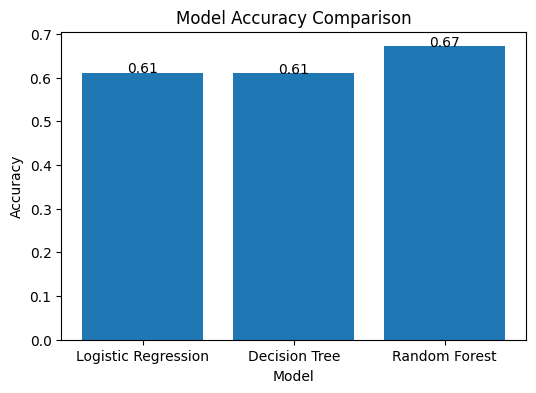

In [ ]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"] # Here we reate a bar chart comparing model accuracies
accuracies = [accuracy, dt_accuracy, rf_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

# add values on top
for i, v in enumerate(accuracies):
    plt.text(i, v, str(round(v, 2)), ha='center')
plt.show()

The feature importance results from the logistic regression model show that sleep hours and social support have positive contributions, suggesting they are associated with lower mental health risk. In contrast, anxiety and depression scores have the strongest negative contributions, indicating they are key factors associated with higher mental health risk. Stress-related variables also contribute, but to a lesser extent. In addition to logistic regression, decision tree and random forest models were implemented to compare predictive performance. The logistic regression and decision tree models achieved similar accuracies of approximately 61%, while the random forest model performed better with an accuracy of about 67%. This suggests that more complex models may better capture the relationships between variables. Overall, these results indicate that psychological factors and sleep play the most significant roles in predicting mental health risk.

---
## Conclusion

Mental health risk can be predicted using lifestyle and psychological factors, with sleep, anxiety, and depression being the most influential variables, although prediction accuracy is moderate due to the complexity of mental health.

Github Repository Link: https://github.com/haydenbudhan/CSC108_MentalHealthPrediction